# Pertemuan 12 - Asosiasi Data & Sistem Rekomendasi Dasar

**Nama:** Moch Faris Oldie  
**NIM:** 250401020048  
**Kelas:** IF401

**Tujuan:** mempelajari Association Rule Mining dengan algoritma Apriori (Market Basket Analysis) menggunakan mlxtend, serta membangun sistem rekomendasi sederhana berbasis Content-Based Filtering.

## 1. Generate & Eksplorasi Dataset Transaksi

Buat 50 transaksi belanja sintetis dari 10 produk, lalu suntikkan pola tersembunyi 'Roti sering dibeli bersama Selai'.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append([str(x) for x in np.random.choice(produk, n_item, replace=False)])

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi :', len(transaksi))

Contoh transaksi: [['Keju', 'Roti', 'Mentega', 'Kopi', 'Selai'], ['Roti', 'Kopi', 'Teh', 'Selai', 'Mentega'], ['Kopi', 'Susu', 'Teh']]
Jumlah transaksi : 50


In [2]:
from collections import Counter

frekuensi = Counter(item for t in transaksi for item in t)
freq_df = pd.DataFrame(frekuensi.items(), columns=['Produk', 'Frekuensi'])
freq_df = freq_df.sort_values('Frekuensi', ascending=False)
print(freq_df.to_string(index=False))

 Produk  Frekuensi
  Selai         26
    Teh         23
Mentega         21
  Telur         18
   Keju         17
   Roti         16
   Kopi         16
   Susu         16
   Gula         16
 Sereal          9


## 2. One-Hot Encoding Transaksi

Ubah daftar transaksi menjadi tabel one-hot encoding menggunakan `TransactionEncoder`.

In [3]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df_transaksi = pd.DataFrame(te_ary, columns=te.columns_)

print(df_transaksi.head())

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


## 3. Cari Frequent Itemset dengan Apriori

Jalankan Apriori dengan beberapa nilai `min_support` dan amati perubahan jumlah itemset.

In [4]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df_transaksi, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

# Gunakan min_support yang menghasilkan jumlah itemset wajar
freq_items = apriori(df_transaksi, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print('\nTop 10 frequent itemset (min_support=0.1):')
print(freq_items.head(10).to_string(index=False))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan

Top 10 frequent itemset (min_support=0.1):
 support                itemsets
    0.52      frozenset({Selai})
    0.46        frozenset({Teh})
    0.42    frozenset({Mentega})
    0.36      frozenset({Telur})
    0.34       frozenset({Keju})
    0.32       frozenset({Gula})
    0.32       frozenset({Kopi})
    0.32       frozenset({Roti})
    0.32       frozenset({Susu})
    0.24 frozenset({Selai, Teh})


## 4. Bentuk & Saring Aturan Asosiasi

Bentuk aturan asosiasi, saring dengan min_confidence dan min_lift > 1, lalu urutkan berdasarkan Lift tertinggi.

In [5]:
from mlxtend.frequent_patterns import association_rules

# Konversi itemset ke str native (kompatibilitas mlxtend dengan numpy 2.x)
freq_items['itemsets'] = freq_items['itemsets'].apply(
    lambda fs: frozenset(str(i) for i in fs))

rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string(index=False))

                antecedents          consequents  support  confidence     lift
     frozenset({Keju, Teh})   frozenset({Telur})     0.12    0.857143 2.380952
frozenset({Selai, Mentega})    frozenset({Kopi})     0.10    0.625000 1.953125
    frozenset({Roti, Gula})   frozenset({Selai})     0.10    1.000000 1.923077
        frozenset({Sereal}) frozenset({Mentega})     0.14    0.777778 1.851852
    frozenset({Telur, Teh})    frozenset({Keju})     0.12    0.600000 1.764706
   frozenset({Selai, Kopi}) frozenset({Mentega})     0.10    0.714286 1.700680
   frozenset({Keju, Telur})     frozenset({Teh})     0.12    0.750000 1.630435
   frozenset({Selai, Gula})    frozenset({Roti})     0.10    0.500000 1.562500
 frozenset({Kopi, Mentega})   frozenset({Selai})     0.10    0.714286 1.373626
          frozenset({Roti})   frozenset({Selai})     0.22    0.687500 1.322115


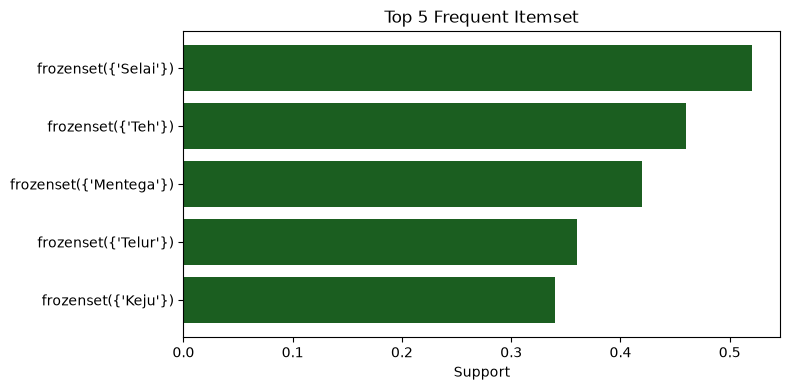

In [6]:
top_items = freq_items.sort_values('support').tail(5)
plt.figure(figsize=(8, 4))
plt.barh(top_items['itemsets'].astype(str), top_items['support'], color='#1B5E20')
plt.xlabel('Support')
plt.title('Top 5 Frequent Itemset')
plt.tight_layout()
plt.show()

**Lift** mengukur kekuatan hubungan dibanding jika kedua item independen. Lift > 1 berarti kedua item cenderung dibeli bersama. Aturan dengan lift tertinggi adalah aturan paling kuat — misalnya Roti → Selai yang sengaja disuntikkan ke dalam data.

## 5. Rekomender Sederhana dengan Content-Based Filtering

Bangun katalog produk dengan kategori, lalu buat rekomendasi produk serupa menggunakan cosine similarity atas kategori (one-hot).

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

for p in ['Roti', 'Susu', 'Kopi']:
    print(f'Mirip dengan {p}:', rekomendasi_serupa(p))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']
Mirip dengan Susu: ['Telur', 'Keju', 'Mentega']
Mirip dengan Kopi: ['Teh', 'Roti', 'Selai']


## 6. Bandingkan Kedua Pendekatan

Bandingkan rekomendasi dari association rules dengan rekomendasi Content-Based untuk produk yang sama.

In [8]:
produk_target = 'Roti'

# Dari association rules: aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]
print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head().to_string(index=False))

print('\nRekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
       consequents     lift
frozenset({Selai}) 1.923077
frozenset({Selai}) 1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


Kedua pendekatan bekerja berbeda: **Association Rules** menemukan produk yang sering dibeli bersama (berbasis frekuensi transaksi), sedangkan **Content-Based** menemukan produk dengan kategori serupa (berbasis atribut). Keduanya saling melengkapi dan dapat digabungkan menjadi sistem hybrid.

## Kesimpulan

Pada pertemuan ini saya mempelajari **Association Rule Mining** dengan algoritma **Apriori** untuk Market Basket Analysis, termasuk konsep support, confidence, dan lift, serta implementasinya menggunakan mlxtend. Saya juga mempelajari konsep **Sistem Rekomendasi**: Collaborative Filtering (berbasis pola perilaku pengguna) dan Content-Based Filtering (berbasis kemiripan atribut item), dan menerapkan rekomendasi berbasis cosine similarity. Temuan utama: aturan Roti → Selai memiliki lift tertinggi karena pola tersebut sengaja disuntikkan, menunjukkan bahwa lift > 1 menandakan hubungan pembelian yang bermakna; rekomendasi Content-Based menyarankan produk kategori serupa. Keterbatasan praktik ini adalah data transaksi masih sintetis dan kecil, serta evaluasi rekomendasi hanya menggunakan konsep kemiripan sederhana tanpa metrik Precision@K pada data uji.